# How to Use GLASS

GLASS (Galaxy Light & AGN Spectral Synthesis) builds **composite SEDs** -
synthetic spectra simulating what an unresolved AGN + host galaxy system
looks like, by mixing a theoretical AGN spectrum with a galaxy spectrum in a
known, tunable proportion $\alpha$. That known mixing gives a controlled
"ground truth" for how much AGN light is present - something real
observations of unresolved sources can't provide on their own.

GLASS was recently reworked to bundle its **entire** underlying dataset
rather than a small sample, and to add generic, fully-parameterized readers
for bringing your own data. This notebook is a tour of what that unlocks:

1. What's actually on disk - the full SKIRTOR AGN torus grid and both Brown
   galaxy/AGN atlases, and how to browse them instead of only using the two
   built-in Type 1 / Type 2 presets.
2. Selecting a custom AGN model and a specific galaxy template by name.
3. The new generic readers, `read_generic_model_grid` and
   `read_generic_sed_templates`, for bring-your-own grids/template folders.
4. Building composite SEDs across the $\alpha$ grid, redshifting them, and
   computing synthetic UVJ/ugr/IRAC colours.

No external data is needed - everything here ships inside the `glass`
package itself.

## 1. Setup

In [45]:
import os
import re
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glass import config, data_io, photometry, visualization
from glass import create_composite_sed, redshift_sed

plt.style.use('default')
visualization.apply_pasa_style()

print(f"SKIRTOR grid:   {config.SKIRTOR_DIR}")
print(f"GALSEDATLAS:    {config.GALSEDATLAS_DIR}")
print(f"AGNSEDATLAS:    {config.AGNSEDATLAS_DIR}")
print(f"Alpha grid:     {config.ALPHA_VALUES}")

SKIRTOR grid:   M:\GitHub\GLASS\src\glass\data\Skirtor
GALSEDATLAS:    M:\GitHub\GLASS\src\glass\data\Brown\GALSEDATLAS
AGNSEDATLAS:    M:\GitHub\GLASS\src\glass\data\Brown\AGNSEDATLAS
Alpha grid:     [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.  ]


## 2. What's bundled: the full SKIRTOR AGN torus grid

The AGN component comes from **SKIRTOR** (Stalevski et al. 2012, 2016), a
radiative-transfer model of the clumpy dusty torus around an AGN's
accretion disk. `config.SKIRTOR_DIR` doesn't hold one file, or even a small
sample - it holds all **19,200** combinations of six torus parameters
(optical depth, two density-gradient exponents, opening angle, radius
ratio, and viewing inclination). Every filename encodes its own parameter
combination, so we can recover the full parameter space directly from what's
on disk rather than trusting documentation to be up to date.

In [46]:
_SKIRTOR_FILENAME_RE = re.compile(
    r'^t(?P<optical_depth>[\d.]+)_p(?P<p>[\d.]+)_q(?P<q>[\d.]+)_'
    r'oa(?P<opening_angle>[\d.]+)_R(?P<radius_ratio>[\d.]+)_'
    r'Mcl(?P<Mcl>[\d.]+)_i(?P<inclination>[\d.]+)_sed\.dat$'
)

grid_values = defaultdict(set)
n_matched = 0
for fname in os.listdir(config.SKIRTOR_DIR):
    match = _SKIRTOR_FILENAME_RE.match(fname)
    if match:
        n_matched += 1
        for key, val in match.groupdict().items():
            grid_values[key].add(float(val))

print(f"{n_matched} SKIRTOR SED files found on disk\n")
for key in ['optical_depth', 'p', 'q', 'opening_angle', 'radius_ratio', 'Mcl', 'inclination']:
    print(f"  {key:>14s}: {sorted(grid_values[key])}")

19200 SKIRTOR SED files found on disk

   optical_depth: [3.0, 5.0, 7.0, 9.0, 11.0]
               p: [0.0, 0.5, 1.0, 1.5]
               q: [0.0, 0.5, 1.0, 1.5]
   opening_angle: [10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0]
    radius_ratio: [10.0, 20.0, 30.0]
             Mcl: [0.97]
     inclination: [0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0]


**What to look for**: `Mcl` only ever takes one value (0.97) - it isn't a
free parameter in this release of the grid - while the other six parameters
each have several allowed values, and *every* combination of them exists as
a file (5 x 4 x 4 x 8 x 3 x 10 = 19,200, matching the count above).

`config.SKIRTOR_TYPE1_PARAMS` and `SKIRTOR_TYPE2_PARAMS` are just two fixed
points in that space - the same torus geometry, viewed face-on (Type 1,
unobscured) versus edge-on (Type 2, obscured):

In [47]:
print("Type 1 (face-on) preset:", config.SKIRTOR_TYPE1_PARAMS)
print("Type 2 (edge-on) preset: ", config.SKIRTOR_TYPE2_PARAMS)
print("\n->  only `inclination` differs between the two presets;")
print("    optical_depth/p/q/opening_angle/radius_ratio are fixed the same")
print("    for both, and never explored elsewhere in the package.")

Type 1 (face-on) preset: {'optical_depth': 7, 'p': 0.5, 'q': 0, 'opening_angle': 40, 'radius_ratio': 20, 'inclination': 0}
Type 2 (edge-on) preset:  {'optical_depth': 7, 'p': 0.5, 'q': 0, 'opening_angle': 40, 'radius_ratio': 20, 'inclination': 90}

->  only `inclination` differs between the two presets;
    optical_depth/p/q/opening_angle/radius_ratio are fixed the same
    for both, and never explored elsewhere in the package.


## 3. Selecting a custom AGN model from the grid

`data_io.read_skirtor_model` takes the six torus parameters directly, so any
grid point can be loaded - not just the two presets. Below, alongside Type 1
and Type 2, we load a **custom** combination with a different optical depth,
density-gradient exponents, opening angle, and radius ratio, to see how much
more the torus geometry can change the spectrum beyond just inclination.

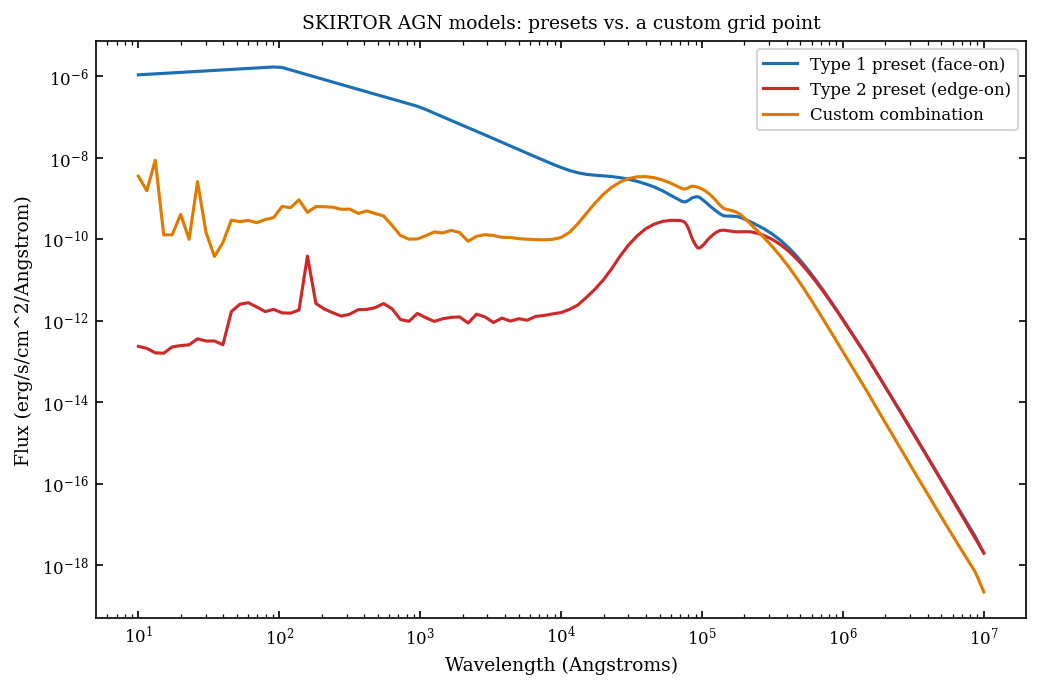

In [48]:
CUSTOM_SKIRTOR_PARAMS = {
    'optical_depth': 3,     # <-- change any of these and re-run
    'p': 1.5,
    'q': 1.5,
    'opening_angle': 80,
    'radius_ratio': 10,
    'inclination': 60,
}

type1_agn_df = data_io.read_skirtor_model(config.SKIRTOR_DIR, **config.SKIRTOR_TYPE1_PARAMS)
type2_agn_df = data_io.read_skirtor_model(config.SKIRTOR_DIR, **config.SKIRTOR_TYPE2_PARAMS)
custom_agn_df = data_io.read_skirtor_model(config.SKIRTOR_DIR, **CUSTOM_SKIRTOR_PARAMS)

fig, ax = plt.subplots(figsize=(8, 5))
for label, df, color in [
    ('Type 1 preset (face-on)', type1_agn_df, '#1A6FB5'),
    ('Type 2 preset (edge-on)', type2_agn_df, '#CC2929'),
    ('Custom combination', custom_agn_df, '#E07B00'),
]:
    ax.loglog(df['lambda (Angstroms)'], df['Total Flux (erg/s/cm^2/Angstrom)'], color=color, label=label)

ax.set_xlabel('Wavelength (Angstroms)')
ax.set_ylabel('Flux (erg/s/cm^2/Angstrom)')
ax.set_title('SKIRTOR AGN models: presets vs. a custom grid point')
ax.legend()
plt.show()

**What to look for**: the two presets differ only in the near-/mid-IR bump
where the torus's own thermal dust emission dominates - inclination mostly
changes how much of the obscured accretion-disk continuum you see directly.
The custom combination, with a different opening angle and radius ratio,
shifts the shape of that dust bump itself, since those parameters control
the torus's actual geometry rather than just the viewing angle.

## 4. Browsing the Brown galaxy & AGN atlases

The galaxy component is an empirical rest-frame template standing in for a
real host galaxy's stellar-population light. `config.GALSEDATLAS_DIR` and
`config.AGNSEDATLAS_DIR` bundle two full empirical atlases (Brown et al.
2014 and 2019) rather than a handful of examples - `read_brown_galaxy_templates`
and `read_agnsedatlas_templates` load every template in a folder at once,
returning a `(df_list, objname_list)` pair you can search by name.

In [49]:
galsedatlas_dfs, galsedatlas_names = data_io.read_brown_galaxy_templates(config.GALSEDATLAS_DIR)
agnsedatlas_dfs, agnsedatlas_names = data_io.read_agnsedatlas_templates(config.AGNSEDATLAS_DIR)

print(f"GALSEDATLAS: {len(galsedatlas_names)} galaxy templates, e.g. {galsedatlas_names[:5]}")
print(f"AGNSEDATLAS: {len(agnsedatlas_names)} AGN/Seyfert templates, e.g. {agnsedatlas_names[:5]}")

GALSEDATLAS: 129 galaxy templates, e.g. ['ARP_118', 'ARP_256_N', 'ARP_256_S', 'CGCG_049_057', 'CGCG_436_030']
AGNSEDATLAS: 113 AGN/Seyfert templates, e.g. ['2MASXJ13000533+1632151', '3C120', '3C273', '3C351', '3C390_3']


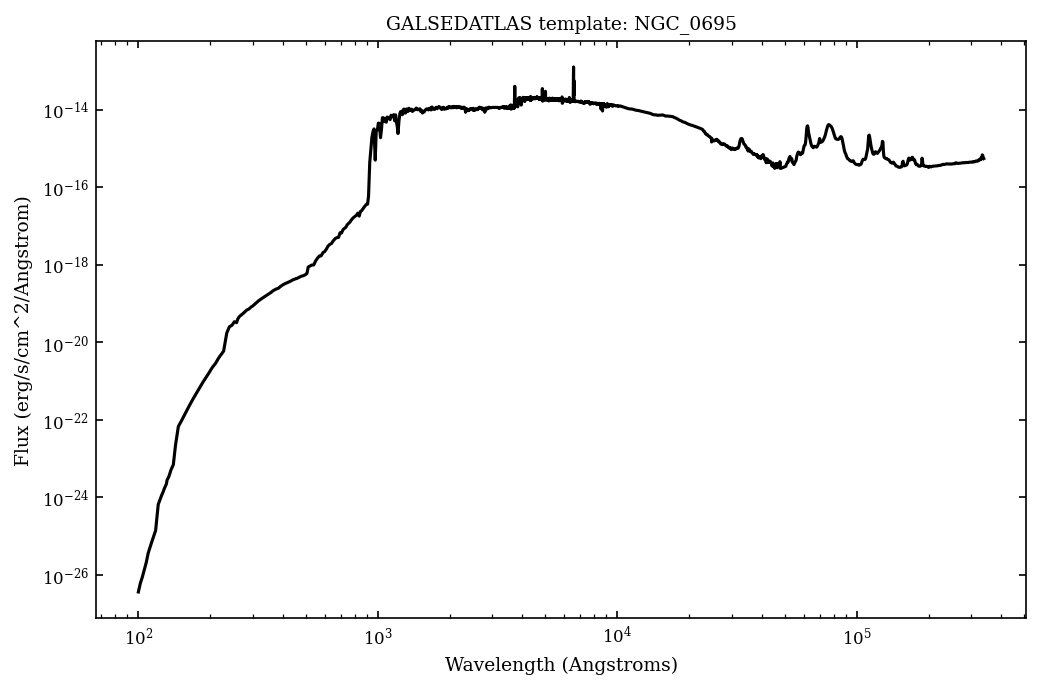

In [50]:
CHOSEN_GALAXY_NAME = 'NGC_0695'  # <-- pick any name printed above and re-run

gal_df = galsedatlas_dfs[galsedatlas_names.index(CHOSEN_GALAXY_NAME)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(gal_df['lambda (Angstroms)'], gal_df['Total Flux (erg/s/cm^2/Angstrom)'], color='k')
ax.set_xlabel('Wavelength (Angstroms)')
ax.set_ylabel('Flux (erg/s/cm^2/Angstrom)')
ax.set_title(f'GALSEDATLAS template: {CHOSEN_GALAXY_NAME}')
plt.show()

## 5. Generic readers: bring your own grid or template folder

`read_skirtor_model` and `read_brown_galaxy_templates` are convenience
wrappers around a specific file layout each. `data_io.py` also has two
**generic** readers with every format detail exposed as a parameter -
`read_generic_model_grid` for a parametrized grid (the SKIRTOR shape) and
`read_generic_sed_templates` for a folder of one-file-per-object templates
(the Brown shape). They're for data GLASS doesn't already have a
format-specific reader for, but to see exactly what they do, we can point
them at the *same* bundled files used above and confirm they reproduce
identical results.

In [51]:
# read_generic_model_grid reproducing read_skirtor_model for CUSTOM_SKIRTOR_PARAMS
generic_agn_df = data_io.read_generic_model_grid(
    config.SKIRTOR_DIR,
    filename_template='t{optical_depth}_p{p}_q{q}_oa{opening_angle}_R{radius_ratio}_Mcl0.97_i{inclination}_sed.dat',
    params=CUSTOM_SKIRTOR_PARAMS,
    wavelength_col=0, flux_col=1,
    wavelength_unit='micron', flux_unit='W/m2',
)

np.testing.assert_allclose(
    generic_agn_df['lambda (Angstroms)'].values, custom_agn_df['lambda (Angstroms)'].values,
)
np.testing.assert_allclose(
    generic_agn_df['Total Flux (erg/s/cm^2/Angstrom)'].values,
    custom_agn_df['Total Flux (erg/s/cm^2/Angstrom)'].values,
)
print("read_generic_model_grid reproduces read_skirtor_model exactly for the custom combination.")

read_generic_model_grid reproduces read_skirtor_model exactly for the custom combination.


In [52]:
# read_generic_sed_templates reproducing read_brown_galaxy_templates for CHOSEN_GALAXY_NAME
chosen_filename = f'hlsp_galsedatlas_multi_multi_{CHOSEN_GALAXY_NAME.lower().replace("_", "-")}_multi_v1_spec.dat'

generic_gal_dfs, generic_gal_names = data_io.read_generic_sed_templates(
    config.GALSEDATLAS_DIR,
    file_pattern=chosen_filename,
    wavelength_col=0, flux_col=1,
    wavelength_unit='angstrom',
    name_pattern=r'multi_multi_(.+)_multi_v1_spec\.dat$',
)

print(f"Generic reader found: {generic_gal_names}")
np.testing.assert_allclose(
    generic_gal_dfs[0]['Total Flux (erg/s/cm^2/Angstrom)'].values,
    gal_df['Total Flux (erg/s/cm^2/Angstrom)'].values,
)
print("read_generic_sed_templates reproduces read_brown_galaxy_templates exactly for", CHOSEN_GALAXY_NAME)

Generic reader found: ['ngc-0695']
read_generic_sed_templates reproduces read_brown_galaxy_templates exactly for NGC_0695


This is exactly the mechanism to reach for when pointing GLASS at a
template library or model grid it has no purpose-built reader for -
SWIRE with a different column order, a different AGN torus grid entirely,
anything with a folder-of-files or one-file-per-parameter-combination
shape.

## 6. Building composite SEDs across the $\alpha$ grid

`create_composite_sed(agn_df, gal_df, alpha)` aligns the two spectra to a
common wavelength grid, renormalizes the AGN spectrum to equal integrated
flux with the galaxy over their overlap, then mixes them by $\alpha$:

$$
F_{\text{composite}}(\lambda) = F_{\text{gal}}(\lambda) + \alpha\, S\, F_{\text{AGN}}(\lambda)
$$

Sweeping $\alpha$ over `config.ALPHA_VALUES` (11 steps from 0 to 1) turns
our one custom AGN model and one chosen galaxy into a full sequence from
pure galaxy to AGN-dominated.

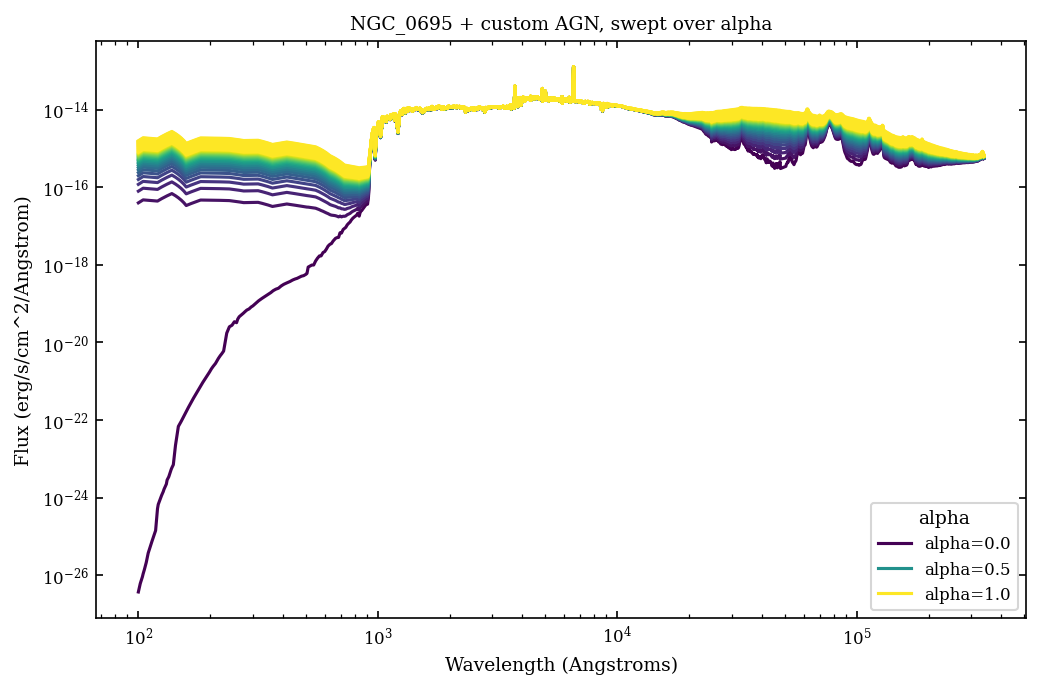

In [53]:
composite_by_alpha = {
    alpha: create_composite_sed(custom_agn_df, gal_df, alpha)
    for alpha in config.ALPHA_VALUES
}

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis
for alpha, composite_df in composite_by_alpha.items():
    ax.loglog(composite_df['lambda (Angstroms)'], composite_df['Total Flux (erg/s/cm^2/Angstrom)'],
              color=cmap(alpha), label=f'alpha={alpha:.1f}' if alpha in (0.0, 0.5, 1.0) else None)

ax.set_xlabel('Wavelength (Angstroms)')
ax.set_ylabel('Flux (erg/s/cm^2/Angstrom)')
ax.set_title(f'{CHOSEN_GALAXY_NAME} + custom AGN, swept over alpha')
ax.legend(title='alpha')
plt.show()

`redshift_sed(sed_df, z)` stretches wavelength by $(1+z)$ and dims flux by
the same factor - the wavelength-dilation + energy-dilution effect of
redshift alone, used throughout this pipeline for getting observed-frame
colours from rest-frame composites.

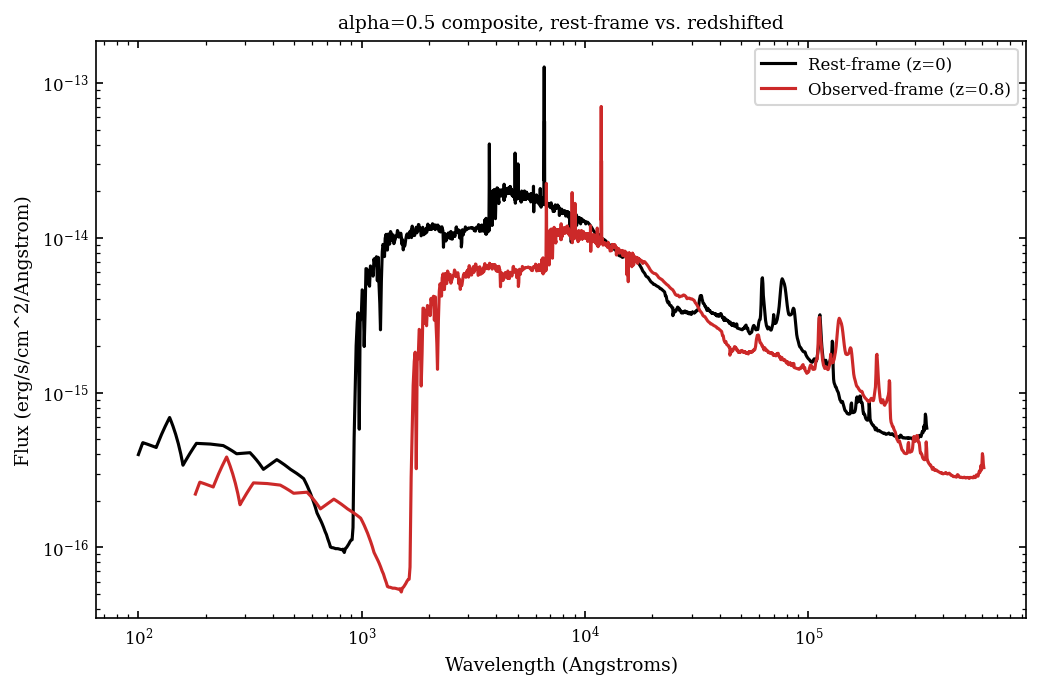

In [54]:
OBSERVED_REDSHIFT = 0.8  # <-- change and re-run

rest_composite = composite_by_alpha[0.5]
observed_composite = redshift_sed(rest_composite, z=OBSERVED_REDSHIFT)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(rest_composite['lambda (Angstroms)'], rest_composite['Total Flux (erg/s/cm^2/Angstrom)'],
          color='k', label='Rest-frame (z=0)')
ax.loglog(observed_composite['lambda (Angstroms)'], observed_composite['Total Flux (erg/s/cm^2/Angstrom)'],
          color='#CC2929', label=f'Observed-frame (z={OBSERVED_REDSHIFT})')
ax.set_xlabel('Wavelength (Angstroms)')
ax.set_ylabel('Flux (erg/s/cm^2/Angstrom)')
ax.set_title('alpha=0.5 composite, rest-frame vs. redshifted')
ax.legend()
plt.show()

## 7. Synthetic photometry & colour-colour classification

`photometry.py` integrates a spectrum against passband transmission curves
to get synthetic magnitudes and colours - UVJ (rest-frame quiescent/
star-forming/dusty selection), ugr (U-dropout selection), and IRAC/Lacy
(mid-IR AGN selection). `calculate_ugr_colours`/`calculate_irac_colours`
take a `redshift=` keyword directly and redshift internally.

**Why inclination, and not the custom combination from Section 3**:
`inclination` is the one SKIRTOR parameter that isolates *how much of the
AGN's direct UV/optical light escapes the torus at all* - everything else
(including Section 3's custom combination) mostly reshapes the infrared
dust bump instead. So rather than Type 1/Type 2 alone, this section sweeps
**five** inclinations at the Type 1/Type 2 presets' own fixed torus geometry
(`optical_depth=7, p=0.5, q=0, opening_angle=40, radius_ratio=20` -
`config.SKIRTOR_TYPE1_PARAMS`/`TYPE2_PARAMS` in Section 3, only ever varying
`inclination` between the two of them) - `i=0` (Type 1) and `i=90` (Type 2)
plus three in between. Quantitatively (`create_composite_sed` at alpha=0 vs.
alpha=1, rest-frame $\Delta(U{-}V, V{-}J)$ distance), scanning every 10
degrees:

| `inclination` | NGC_0337 | NGC_4552 | IC_4553 |
|---|---|---|---|
| 0 (Type 1) | 0.232 mag | 0.733 mag | 1.087 mag |
| 30 | 0.226 mag | 0.717 mag | 1.072 mag |
| 40 | 0.220 mag | 0.702 mag | 1.057 mag |
| 50 | 0.103 mag | 0.117 mag | 0.309 mag |
| 60 | 0.007 mag | 0.006 mag | 0.018 mag |
| 70 | 0.007 mag | 0.004 mag | 0.015 mag |
| 90 (Type 2) | 0.002 mag | 0.001 mag | 0.004 mag |

This isn't a smooth ramp - it's a **knee**. Nothing changes much between
`i=0` and `i=40`, everything changes between `i=40` and `i=60`, and nothing
changes much again from `i=60` to `i=90`. That's `opening_angle=40` made
visible: SKIRTOR's `opening_angle` sets the half-angle, measured from the
pole, of the torus's clear polar cavity - inside it (`i` up to roughly
`90 - opening_angle = 50`), you're looking straight down the cavity at the
unobscured accretion disk; past it, you're looking through the dusty torus
body itself. `i=30` and `i=70` - both close to the flat plateaus either
side of that knee - still show it: `i=30` looks almost exactly like Type 1,
`i=70` already looks almost exactly like Type 2. `i=50` is added here too,
since it's the only one of the five that actually sits *inside* the
transition and shows a partial effect.

Same three representative GALSEDATLAS templates as Section 6
(`notebooks/UVJ_Colour_Evolution.ipynb`'s own Figure 6 picks - one per UVJ
population), now built against all five inclinations:

In [55]:
REP_TEMPLATES = {
    'Star-forming': 'NGC_0337',
    'Quiescent': 'NGC_4552',
    'Dusty': 'IC_4553',
}

_INCLINATION_BASE = {k: v for k, v in config.SKIRTOR_TYPE1_PARAMS.items() if k != 'inclination'}
AGN_MODELS = {
    f'i={incl}' if incl not in (0, 90) else ('Type 1 (i=0)' if incl == 0 else 'Type 2 (i=90)'): (
        type1_agn_df if incl == 0 else type2_agn_df if incl == 90
        else data_io.read_skirtor_model(config.SKIRTOR_DIR, inclination=incl, **_INCLINATION_BASE)
    )
    for incl in [0, 30, 50, 70, 90]
}
UGR_AGN_TYPES = ['Type 1 (i=0)', 'Type 2 (i=90)']  # Section 7b keeps just the two extremes - see its own note

passbands = photometry.load_passbands(config.FILTER_PATHS)
alphas_arr = list(config.ALPHA_VALUES)

rep_composites = {
    pop: {
        agn_name: {
            alpha: create_composite_sed(agn_df, galsedatlas_dfs[galsedatlas_names.index(name)], alpha)
            for alpha in alphas_arr
        }
        for agn_name, agn_df in AGN_MODELS.items()
    }
    for pop, name in REP_TEMPLATES.items()
}


_LABEL_OFFSETS = [(5, 4), (5, -11), (-9, 4)]  # cycled per population so labels don't stack


def plot_alpha_track(ax, xs, ys, alphas, label=None, offset_idx=0):
    """Colour-coded alpha=0 -> alpha=1 track for one template: a line
    segment per alpha step (coloured by alpha), a circle at alpha=0, and a
    star at alpha=1."""
    cmap = plt.cm.plasma
    norm = plt.Normalize(vmin=0, vmax=1)
    for i in range(len(alphas) - 1):
        ax.plot(xs[i:i + 2], ys[i:i + 2], color=cmap(norm(alphas[i])), linewidth=2, solid_capstyle='round')
    ax.scatter(xs[0], ys[0], color=cmap(norm(0.0)), s=45, zorder=5, edgecolor='k', linewidth=0.6)
    ax.scatter(xs[-1], ys[-1], color=cmap(norm(1.0)), s=70, marker='*', zorder=5, edgecolor='k', linewidth=0.6)
    if label:
        dx, dy = _LABEL_OFFSETS[offset_idx % len(_LABEL_OFFSETS)]
        ha = 'left' if dx >= 0 else 'right'
        ax.annotate(label, (xs[0], ys[0]), fontsize=7, xytext=(dx, dy), textcoords='offset points',
                    fontweight='bold', ha=ha)

### 7a. UVJ - rest-frame, across the inclination knee

`plot_uvj_diagram` fixes its axis limits (and the Quiescent/Star-forming/
Dusty wedge and labels) to the standard UVJ selection box, so we plot it
with empty data first to draw that fixed context on each panel, then overlay
one alpha=0->1 track per representative template on each of the five
inclinations - the two-panel Type 1/Type 2 version of this layout is
`student_edition/Synthetic_SED_Walkthrough.ipynb` Section 8.2 and
`UVJ_Colour_Evolution.ipynb`'s own Figure 4/5; this extends it across the
`i=0..90` sweep from the table above.

Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.00
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.05
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.10
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.15
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.20
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.25
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.30
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.35
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.40
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.45
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.50
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.55
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.60
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.65
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.70
Calculating UVJ for Star-forming + Type 1 (i=0) at alpha=0.75
Calculat

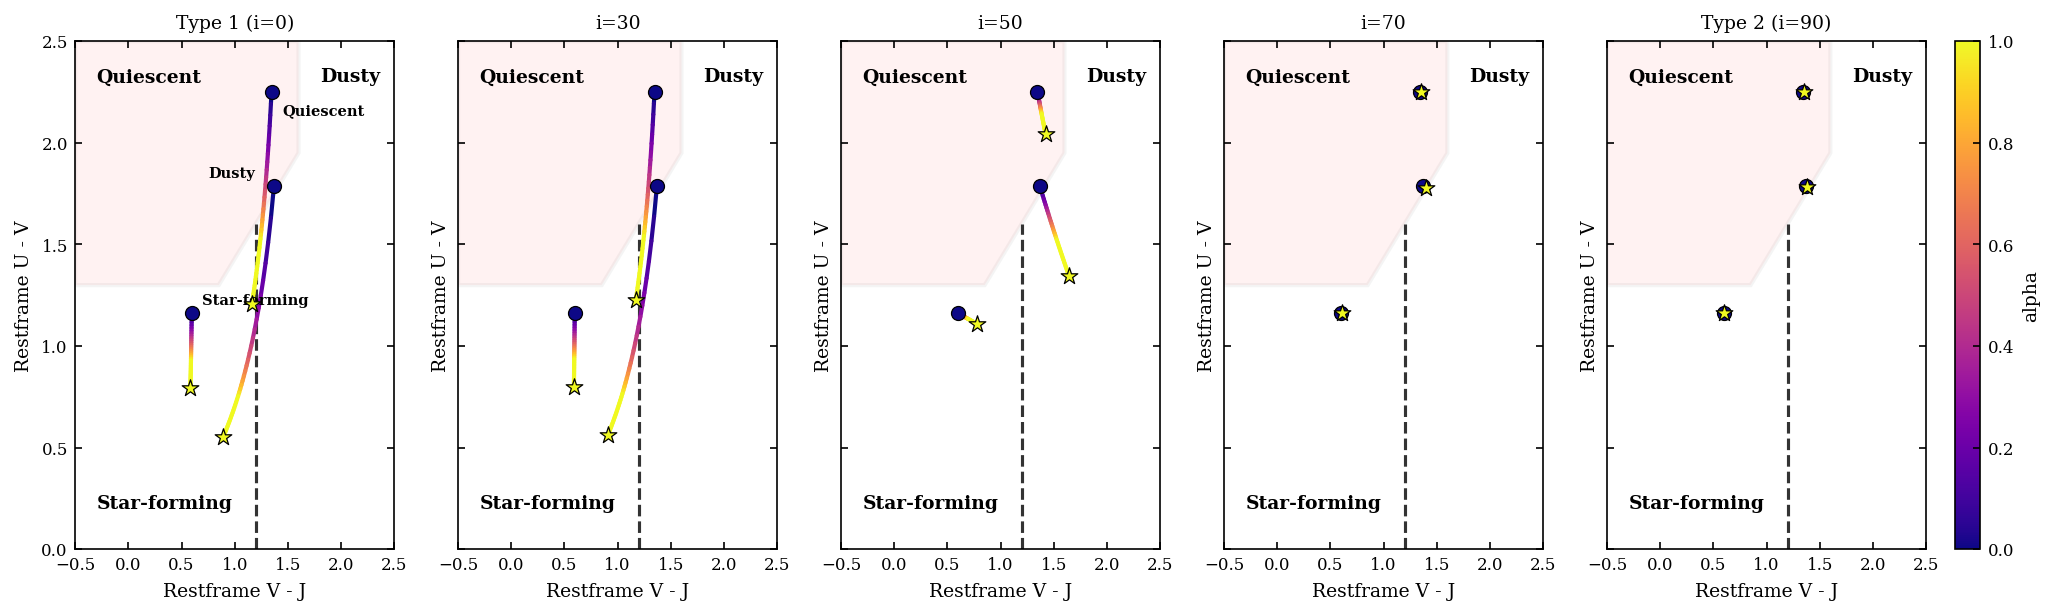

In [56]:
fig, axes = plt.subplots(1, len(AGN_MODELS), figsize=(3.3 * len(AGN_MODELS), 4.4), sharex=True, sharey=True)

for ax, agn_name in zip(axes, AGN_MODELS):
    visualization.plot_uvj_diagram([], [], ax=ax, title=agn_name)
    for i, pop in enumerate(REP_TEMPLATES):
        uv_vals, vj_vals = [], []
        for alpha in alphas_arr:
            print(f"Calculating UVJ for {pop} + {agn_name} at alpha={alpha:.2f}")
            uv, vj = photometry.calculate_UVJ_colours(rep_composites[pop][agn_name][alpha],
                                                        passbands['U'], passbands['V'], passbands['J'])
            uv_vals.append(uv)
            vj_vals.append(vj)
        plot_alpha_track(ax, vj_vals, uv_vals, alphas_arr,
                          label=pop if agn_name == 'Type 1 (i=0)' else None, offset_idx=i)

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.015, label='alpha')
plt.show()

**What to look for** (checked against `classify_uvj`, not eyeballed): the
`i=0` and `i=30` panels look almost identical - both cross `NGC_4552`
(labelled Quiescent) all the way into Dusty and `IC_4553` (labelled Dusty)
into Star-forming, exactly the "large leaps" table above predicts for that
plateau. `i=50` sits visibly *between* the extremes: `IC_4553` still crosses
into Dusty, but the shift is smaller and `NGC_4552` no longer crosses at
all. `i=70` and `i=90` again look almost identical to each other - and
almost static - matching the table's second plateau. `NGC_0337` never
changes classification anywhere in the sweep, despite moving a similar
distance to `NGC_4552` at low inclination (Section 7's table: 0.23 vs. 0.73
mag) - it simply starts further from a boundary to begin with.

One more thing worth noticing before trusting a label: `IC_4553` is picked
here as the "Dusty" archetype for its physical type (a dust-reddened
starburst), but at alpha=0 - no AGN at all - `classify_uvj` actually puts it
in the **Quiescent** region, not Dusty. That's a real, known effect (heavily
dust-reddened star formation can mimic an old stellar population's colour),
not a bug - and exactly why `notebooks/UVJ_Template_Selector.ipynb` exists:
to check a template's *actual* UVJ position rather than assume it from its
physical description.

### 7b. ugr - U-dropout selection needs a redshift *and* a specific one

Unlike UVJ, the ugr U-dropout wedge is only meaningful at a redshift where
the Lyman break has actually moved into the observed `u` band - the project's
own figures (`Paper_Results_Master.ipynb`, `CIGALE_Decomposition_Analysis.ipynb`)
redshift every composite to a single fixed `z_ugr = 3.0`, the centre of the
selection's target window (2.6 < z < 3.6); `student_edition/Synthetic_SED_Walkthrough.ipynb`
Section 8.3 does the same for the same reason.

To see *why* that window matters - not just adopt it - this sweeps a few
redshifts around it (one below, one inside, one above) **and** AGN type, so
both axes of the effect are visible at once: which redshifts put a source in
the wedge at all, and which AGN type is capable of moving it back out. This
uses just the two extremes (`UGR_AGN_TYPES`), not all five inclinations from
7a/7c - a 5x3 = 15-panel grid is more than this one point needs, and Section
7a's knee already tells us `i=30`/`i=70` would look almost identical to
`i=0`/`i=90` here too; swap `UGR_AGN_TYPES` for `AGN_MODELS` below to see
that for yourself.

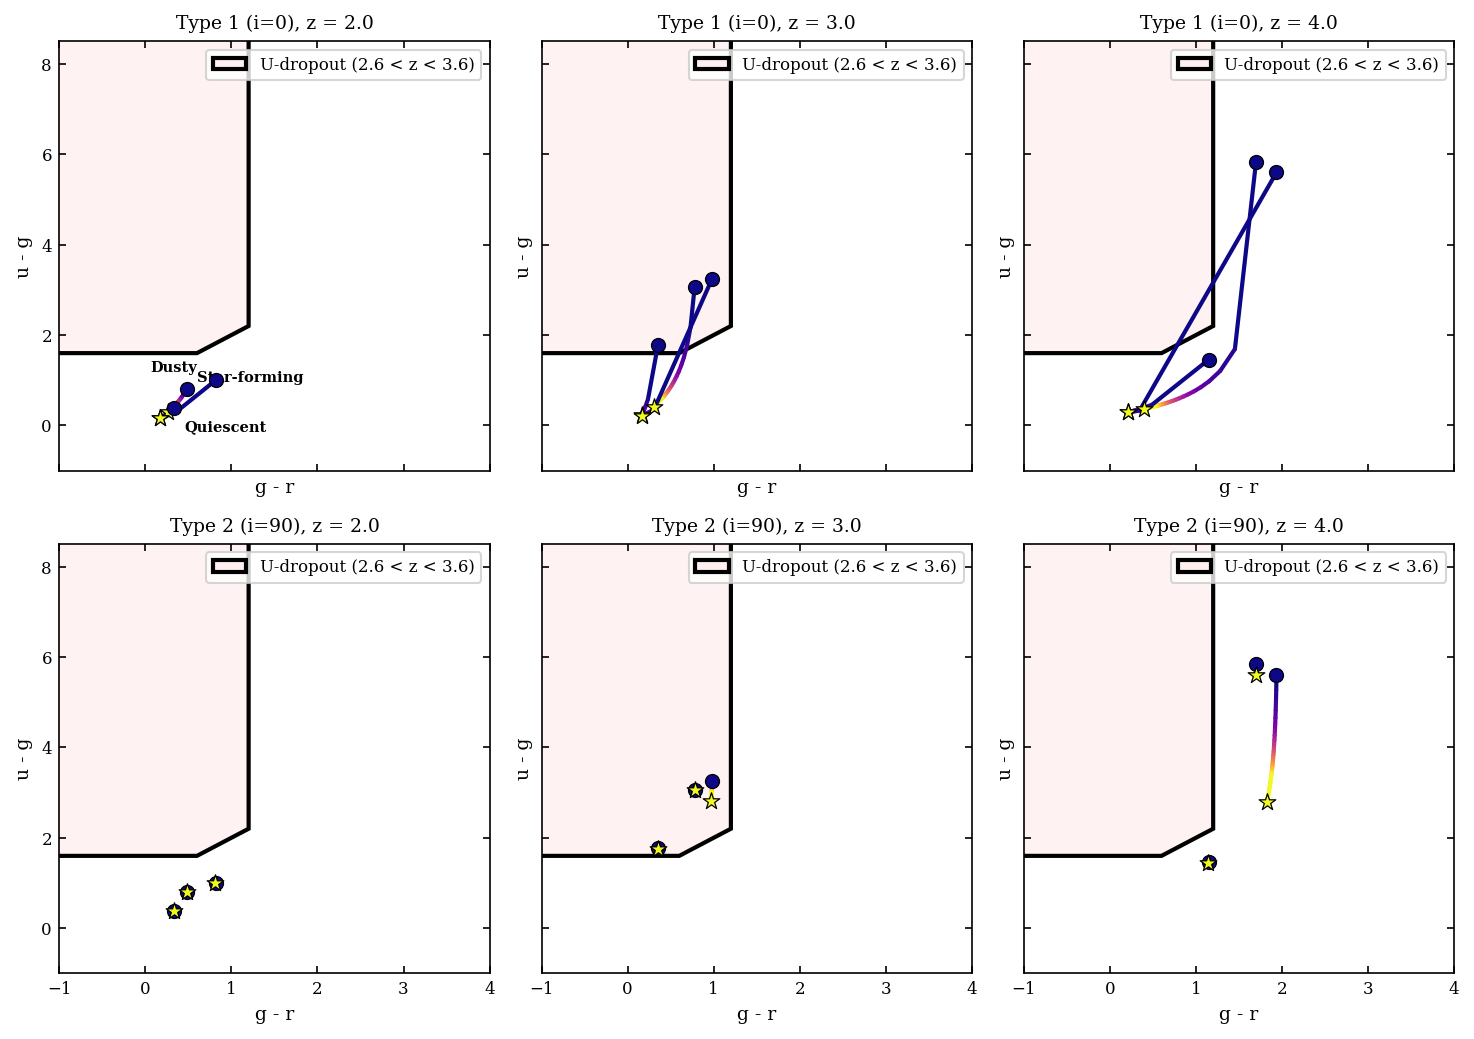

In [57]:
UGR_REDSHIFTS = [2.0, 3.0, 4.0]  # below / inside / above the 2.6 < z < 3.6 target window

fig, axes = plt.subplots(2, len(UGR_REDSHIFTS), figsize=(3.3 * len(UGR_REDSHIFTS), 7.0), sharex=True, sharey=True)
for row, agn_name in zip(axes, UGR_AGN_TYPES):
    for ax, z in zip(row, UGR_REDSHIFTS):
        visualization.plot_ugr_diagram([], [], ax=ax, title=f'{agn_name}, z = {z}')
        for i, pop in enumerate(REP_TEMPLATES):
            ug_vals, gr_vals = [], []
            for alpha in alphas_arr:
                ug, gr = photometry.calculate_ugr_colours(rep_composites[pop][agn_name][alpha],
                                                            passbands['u'], passbands['g'], passbands['r'], redshift=z)
                ug_vals.append(ug)
                gr_vals.append(gr)
            label = pop if (agn_name == UGR_AGN_TYPES[0] and z == UGR_REDSHIFTS[0]) else None
            plot_alpha_track(ax, gr_vals, ug_vals, alphas_arr, label=label, offset_idx=i)
plt.tight_layout()
plt.show()

**What to look for**: at `z = 3.0` (inside the target window), all three
templates start (alpha=0, circle) inside the wedge in both rows - a genuine
dropout signature, since redshifting to z=3 moves each spectrum's Lyman
break into the observed `u` band regardless of AGN type. The rows then
diverge exactly as Section 7a predicted: in the **Type 1** row every track
is pulled straight out of the wedge as alpha increases (the unobscured blue
continuum refills the `u` band and erases the dropout signature), while in
the **Type 2** row the tracks barely move and stay inside. At `z = 2.0` and
`z = 4.0`, the break sits outside the `u`/`g` pair entirely, so the tracks
start outside the wedge in both rows regardless of AGN type - a reminder
that AGN contamination and redshift are two *independent* knobs on this
diagram, not one.

### 7c. IRAC/Lacy - rest-frame, matching this project's own validation figure

`notebooks/Model_Validation_via_IRAC.ipynb` evaluates the Lacy wedge at
**rest-frame** (`z_irac = 0.0`, its own inline comment: "Restframe for
standard Lacy wedge demo") to isolate how much the AGN *itself* moves a
galaxy's mid-IR colour, independent of any survey's redshift distribution -
we match that convention here for the same reason. (Note this differs from
`student_edition/Synthetic_SED_Walkthrough.ipynb` Section 8.4, which instead
redshifts to one illustrative observed-frame `z=0.5`, framing the Lacy wedge
as an inherently observed-frame diagnostic - both are legitimate framings of
the same tool for different purposes; applying it to a real catalogue where
every object sits at its own redshift is what
`notebooks/Observational_Validation_ZFOURGE.ipynb` does.)

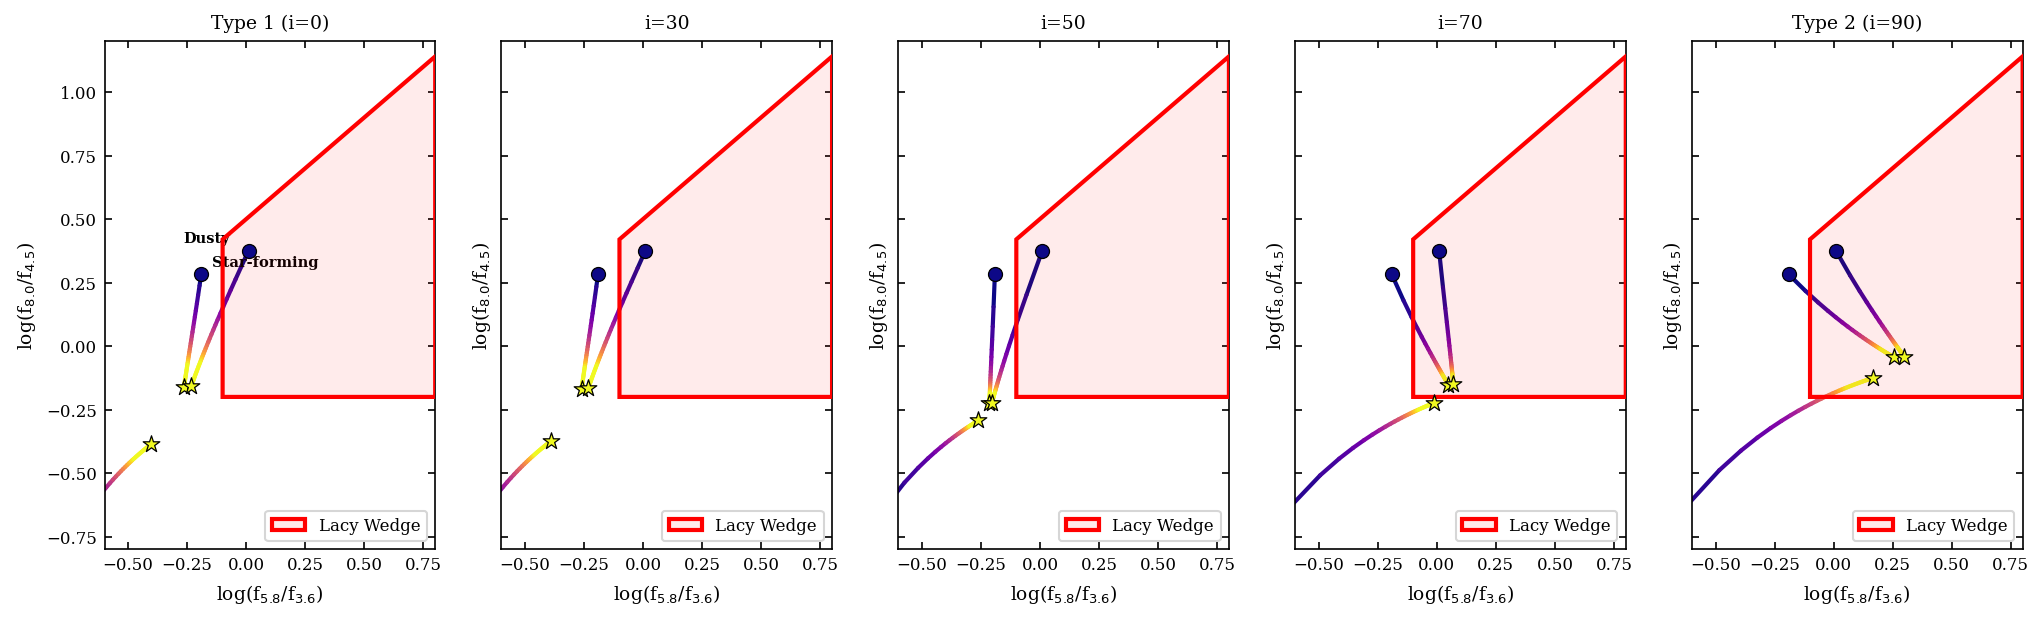

In [58]:
fig, axes = plt.subplots(1, len(AGN_MODELS), figsize=(3.3 * len(AGN_MODELS), 4.4), sharex=True, sharey=True)

for ax, agn_name in zip(axes, AGN_MODELS):
    visualization.plot_irac_diagram([], [], ax=ax, title=agn_name)
    for i, pop in enumerate(REP_TEMPLATES):
        f5836_vals, f8045_vals = [], []
        for alpha in alphas_arr:
            f5836, f8045 = photometry.calculate_irac_colours(rep_composites[pop][agn_name][alpha],
                                                               passbands['3.6'], passbands['4.5'],
                                                               passbands['5.8'], passbands['8.0'], redshift=0.0)
            f5836_vals.append(f5836)
            f8045_vals.append(f8045)
        plot_alpha_track(ax, f5836_vals, f8045_vals, alphas_arr,
                          label=pop if agn_name == 'Type 1 (i=0)' else None, offset_idx=i)
plt.show()

**What to look for** - and this one runs the *opposite* way from UVJ and
ugr, with its own, different-shaped knee: `IC_4553` starts (alpha=0) already
inside the Lacy wedge at every inclination, since its own dust emission
already has roughly the right mid-IR shape. As `alpha` increases, the
`i=0`/`i=30` panels look alike (`IC_4553` pulled back *out* of the wedge,
the other two staying out), `i=50` is nearly identical to those two, and
then `i=70`/`i=90` look alike as a *different* pair (`NGC_0337` and
`IC_4553` both pulled *into* the wedge; `NGC_4552` gets closer at `i=70`
without quite entering, and only crosses in by `i=90`). The transition here
happens later in
the sweep than UVJ's did (between `i=50` and `i=70`, not `i=40` and `i=60`)
- the same five inclinations, but the two diagrams don't agree on exactly
where the knee falls, because they're sensitive to different parts of the
spectrum.

The reversed direction makes sense from the composite equation in Section
6: $S$ renormalizes the *whole* AGN spectrum to match the galaxy's
integrated flux over their shared wavelength range, which for the
unobscured end of the sweep is dominated by an enormous UV/optical
continuum (Section 3's log-log plot). Reaching that same integrated total
therefore buys very little actual mid-IR dust flux once $S$ is applied. The
obscured end has almost no UV/optical continuum to begin with, so its
entire scaled budget goes into the mid-IR dust bump instead - the one part
of the SED the Lacy wedge is actually looking at. Unobscured does not mean
"more detectable as an AGN" here; it depends entirely on which two filters
are doing the looking, echoing Section 7a/7b's UVJ/ugr result from the
opposite direction.

## 8. Recap: where to go next

What's now selectable, rather than fixed to two hardcoded presets:

- **AGN model**: any of the 19,200 SKIRTOR grid points (`read_skirtor_model`),
  found by enumerating what's actually on disk (Section 2).
- **Galaxy/AGN template**: any of the 129 GALSEDATLAS or 113 AGNSEDATLAS
  templates, browsed by name (`read_brown_galaxy_templates`/
  `read_agnsedatlas_templates`).
- **Anything else**: `read_generic_model_grid`/`read_generic_sed_templates`
  for a parametrized grid or template folder GLASS has no dedicated reader
  for - every format detail (column layout, units, filename pattern) is a
  parameter instead of hardcoded.

From here:

- `notebooks/UVJ_Template_Selector.ipynb` ranks every GALSEDATLAS template by
  distance from the UVJ classification boundaries - useful for picking a
  template that sits deliberately close to (or far from) a boundary.
- `notebooks/CIGALE_Decomposition_Analysis.ipynb` uses these same composites
  as ground truth against real CIGALE AGN+galaxy SED fits.
- To work with your **own** CIGALE run's output rather than GLASS's bundled
  data, `data_io.read_cigale_best_model(filepath, redshift=..., restframe=True)`
  reads a `*_best_model.fits` file, and `analysis.decompose_cigale_sed`
  splits it into host/AGN components - both bring-your-own, since GLASS
  doesn't bundle CIGALE output itself.